# How to train a neural network to flag spam

## Abstract

This is an AI pipeline that demonstrates the use of advanced AI tools used to classify messages as 'spam' or 'not spam'. We will be using the Kaggle dataset ([sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)) to train the model to classify different test messages. Python packages such as pandas, PyTorch, and numpy will be used to pre-process and train a model. We will use MatPlotLib to visualise the results as well as visual correlations between data. We will cleanse and tokenise our data so that it can be processed by our neural network.


## Learning Objectives

This tutorial will run through the following:
- Visualizing and understanding imbalanced datasets
- Finding inputs that correlate with the classification outcome
- Preprocessing text data by removing noisy data (stopwords, punctuation, links)
- Using pre-trained tokenizers (DistilBERT) to convert text into tensors
- Building a bidirectional LSTM neural network with PyTorch
- Training and evaluating a PyTorch model for binary classification
- Correctly classifying whether something is 'spam' or 'ham' (not spam)

## Tutorials/sources

The referred tutorials are at the end of this tutorial.

### Pros vs Cons of Sources

| Source | Pros | Cons |
|--------|------|------|
| **[1] NLP GloVe, BERT, TF-IDF, LSTM Explained** | Explained the ins and outs of spam classification and preprocessing. Great graphics which I implemented in my tutorial. | Uses TensorFlow instead of PyTorch (required for coursework). |
| **[2] SMS Spam Classification with BERT** | Explained tokenization very well. Introduced HuggingFace AutoTokenizer which simplified complexity. | Did not train the neural network using PyTorch; used HuggingFace transformers package instead. |
| **[3] Text Classification by Hugging Face** | Very useful for understanding how tokenization and the tokenizer work. | Same as Source [2] - does not use PyTorch for training. |

## Table of Contents
1. [Importing dataset](#importing-dataset)
2. [Label distribution](#label-distribution)
3. [Find correlation between length of message and label](#find-correlation-between-length-of-message-and-label)
4. [Preprocessing data](#preprocessing-data)
5. [Hyperparameter Experiments](#hyperparameter-experiments)
6. [Final Model Training](#final-model-training)
7. [References](#references)

## Importing dataset

In [36]:
import pandas as pd

# Latin1 encoding 
df = pd.read_csv("./spam.csv", encoding='latin1')

# Remove any empty rows
df = df.dropna(how="any", axis=1)
df.columns = ["label","message"]
# Binary values for ham (0) and spam (1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Label distribution

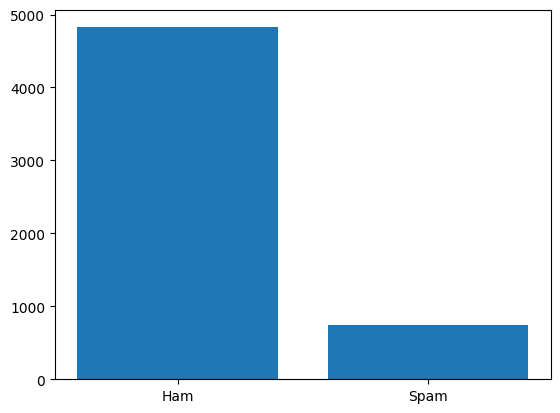

In [37]:
import matplotlib.pyplot as plt
import numpy as np

label_distribution = df.groupby("label")["label"].agg("count").values
label_distribution

x = np.array(["Ham","Spam"])
y = np.array(label_distribution)

plt.bar(x,y)
plt.show()

## Find correlation between length of message and label

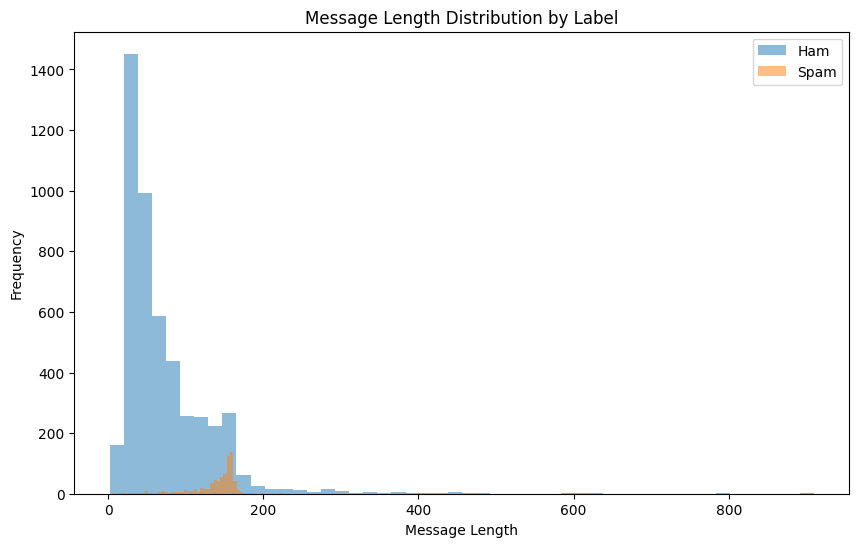

In [38]:
df['message_len'] = df['message'].astype(str).map(len)
df.head()

df.groupby("label")["message_len"].describe()

plt.figure(figsize=(10,6))

# Ham
plt.hist(df[df["label"] == 0]["message_len"], 
         bins=50, alpha=0.5, label="Ham")

# Spam
plt.hist(df[df["label"] == 1]["message_len"], 
         bins=50, alpha=0.5, label="Spam")

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution by Label")
plt.legend()
plt.show()

### Normalized as the dataset is imbalanced

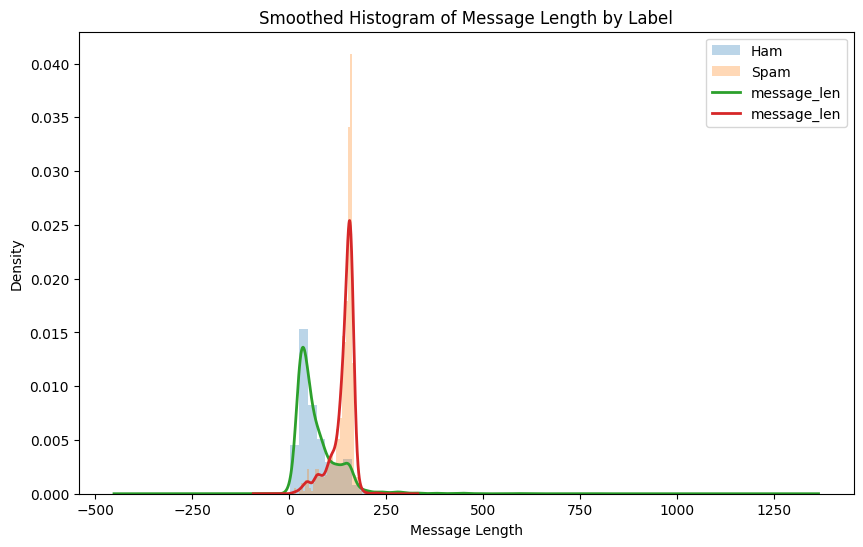

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ham = df[df["label"] == 0]["message_len"]
spam = df[df["label"] == 1]["message_len"]

# Histograms
plt.hist(ham, bins=40, density=True, alpha=0.3, label="Ham")
plt.hist(spam, bins=40, density=True, alpha=0.3, label="Spam")

# KDE lines
ham.plot(kind="kde", linewidth=2)
spam.plot(kind="kde", linewidth=2)

plt.xlabel("Message Length")
plt.ylabel("Density")
plt.title("Smoothed Histogram of Message Length by Label")
plt.legend()
plt.show()

## Preprocessing data

### Text cleaning

In [40]:
# text cleaning as from source [1]

import re
import string

def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text


In [41]:
df['message_clean'] = df['message'].apply(clean_text)
df.head()

### end of source

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,49,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah i dont think he goes to usf he lives aroun...


In [42]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# stopwords processing as from source [1]

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text
    
df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

### end of source [1]

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\costjl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts m...
3,0,U dun say so early hor... U c already then say...,49,dun say early hor already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though


### Splitting training and testing data

In [43]:
from sklearn.model_selection import train_test_split

X = df["message_clean"]
y = df["label"]
lengths = df["message_len"]

X_train, X_test, y_train, y_test , len_train, len_test = train_test_split(
    X, 
    y,
    lengths,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [44]:
# Tokenization as from source [2]
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased", use_fast=True)

### end of source [2]
# source [2] https://www.kaggle.com/code/wesleyacheng/sms-spam-classification-with-bert?scriptVersionId=131649906&cellId=14



train_encoded = tokenizer(
    list(X_train),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

test_encoded = tokenizer(
    list(X_test),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [45]:
train_lengths = torch.tensor(len_train.values, dtype=torch.float32)
test_lengths = torch.tensor(len_test.values, dtype=torch.float32)

In [46]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_encoded["input_ids"],train_lengths.unsqueeze(1), y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


test_dataset = TensorDataset(test_encoded["input_ids"], test_lengths.unsqueeze(1), y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32)

In [47]:
import torch.nn as nn

class SpamRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2 + 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, msg_len):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        combined = torch.cat([hidden, msg_len], dim=1)
        out = self.fc(combined)
        return self.sigmoid(out).squeeze()

In [48]:
vocab_size = tokenizer.vocab_size

## Hyperparameter Experiments

We will compare how different learning rates and number of epochs affect model performance. This helps us understand the impact of these hyperparameters on training.

In [49]:
def train_model(model, train_loader, epochs, lr):
    """Train a model with specified hyperparameters and return training history."""
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'epoch': [], 'loss': []}
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, len_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)
            y_batch = y_batch.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(X_batch, len_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        history['epoch'].append(epoch + 1)
        history['loss'].append(avg_loss)
    
    return history

def evaluate_model(model, test_loader):
    """Evaluate model and return accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, len_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)
            y_batch = y_batch.to(device).float()
            
            outputs = model(X_batch, len_batch)
            predictions = (outputs > 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)
    
    return correct / total

In [50]:
# Define hyperparameter configurations to test
configs = [
    {'lr': 0.01, 'epochs': 5},
    {'lr': 0.001, 'epochs': 5},
    {'lr': 0.0001, 'epochs': 5},
    {'lr': 0.01, 'epochs': 10},
    {'lr': 0.001, 'epochs': 10},
    {'lr': 0.0001, 'epochs': 10},
]

# Store results
results = []
all_histories = {}
output_lines = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_lines.append(f"Using device: {device}")
output_lines.append("=" * 50)

# Train each configuration
for config in configs:
    lr = config['lr']
    epochs = config['epochs']
    
    # Create and train model
    model = SpamRNN(vocab_size=vocab_size).to(device)
    history = train_model(model, train_loader, epochs, lr)
    accuracy = evaluate_model(model, test_loader)
    final_loss = history['loss'][-1]
    
    # Store results
    results.append({
        'Learning Rate': lr,
        'Epochs': epochs,
        'Final Loss': final_loss,
        'Accuracy': accuracy
    })
    all_histories[f"lr={lr}, epochs={epochs}"] = history
    
    # Collect output
    output_lines.append(f"lr={lr}, epochs={epochs} -> Loss: {final_loss:.4f}, Accuracy: {accuracy:.4f}")

output_lines.append("=" * 50)
output_lines.append("Training complete!")

# Print all at once
print("\n".join(output_lines))

Using device: cpu
lr=0.01, epochs=5 -> Loss: 0.0021, Accuracy: 0.9848
lr=0.001, epochs=5 -> Loss: 0.0257, Accuracy: 0.9794
lr=0.0001, epochs=5 -> Loss: 0.1266, Accuracy: 0.9561
lr=0.01, epochs=10 -> Loss: 0.0013, Accuracy: 0.9839
lr=0.001, epochs=10 -> Loss: 0.0017, Accuracy: 0.9767
lr=0.0001, epochs=10 -> Loss: 0.0630, Accuracy: 0.9749
Training complete!


### Results Table

In [51]:
# Display results as a table
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x:.4f}")
results_df['Final Loss'] = results_df['Final Loss'].apply(lambda x: f"{x:.4f}")
results_df

,Learning Rate,Epochs,Final Loss,Accuracy
0,0.0100,5,0.0021,0.9848
1,0.0010,5,0.0257,0.9794
2,0.0001,5,0.1266,0.9561
3,0.0100,10,0.0013,0.9839
4,0.0010,10,0.0017,0.9767
5,0.0001,10,0.0630,0.9749


### Training Loss Curves

Visualizing how the loss decreases over epochs for different configurations:

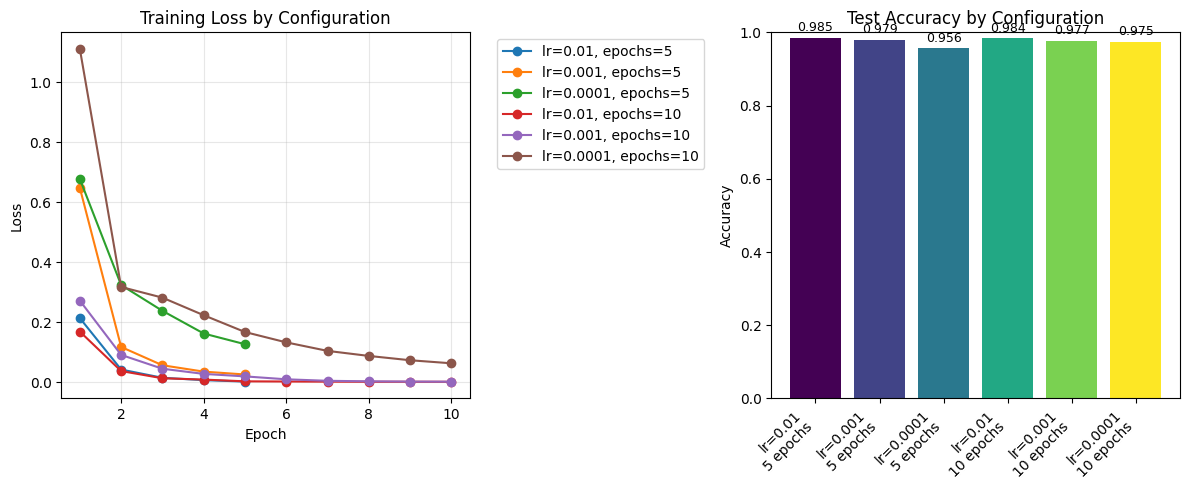

In [52]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss curves for all configurations
plt.subplot(1, 2, 1)
for name, history in all_histories.items():
    plt.plot(history['epoch'], history['loss'], marker='o', label=name)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss by Configuration')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy comparison bar chart
plt.subplot(1, 2, 2)
configs_labels = [f"lr={r['Learning Rate']}\n{r['Epochs']} epochs" for r in results]
accuracies = [float(r['Accuracy']) for r in results]

colors = plt.cm.viridis(np.linspace(0, 1, len(configs_labels)))
bars = plt.bar(range(len(configs_labels)), accuracies, color=colors)
plt.xticks(range(len(configs_labels)), configs_labels, rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Test Accuracy by Configuration')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Analysis

From the experiments above, we can observe:
- **Learning rate impact**: Higher learning rates (0.01) converge very quickly at the start and ease their way towards 0, while lower rates (0.0001) converge more slowly and seem to not have very stable performance.
- **Epochs impact**: More epochs generally lead to better results as seen in the graph above representing the training loss curve.
- **Best configuration**: The optimal balance seems to be 10 epochs with a 0.01 LR. More than 10 epochs seems to have a minimal impact to training loss.

## Final Model Training

Based on the hyperparameter experiments, we now train our final model with the best configuration (LR: 0.01 Epochs: 10):

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpamRNN(vocab_size=vocab_size).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for X_batch, len_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()
        
        optimizer.zero_grad()
        outputs = model(X_batch, len_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 0.2505
Epoch 2 Loss: 0.0878
Epoch 2 Loss: 0.0878
Epoch 3 Loss: 0.0434
Epoch 3 Loss: 0.0434
Epoch 4 Loss: 0.0471
Epoch 4 Loss: 0.0471
Epoch 5 Loss: 0.0202
Epoch 5 Loss: 0.0202
Epoch 6 Loss: 0.0104
Epoch 6 Loss: 0.0104
Epoch 7 Loss: 0.0088
Epoch 7 Loss: 0.0088
Epoch 8 Loss: 0.0051
Epoch 8 Loss: 0.0051
Epoch 9 Loss: 0.0029
Epoch 9 Loss: 0.0029
Epoch 10 Loss: 0.0025
Epoch 10 Loss: 0.0025


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, len_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()

        outputs = model(X_batch, len_batch)
        predictions = (outputs > 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9740


In [ ]:
# Example new message
new_message = "Hey how are you finding work today?"

# Tokenize like before
encoding = tokenizer(
    [new_message],
    padding="max_length",
    truncation=True,
    max_length=train_encoded["input_ids"].shape[1],
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)

# Compute message length
msg_len = torch.tensor([[len(new_message.split())]], dtype=torch.float32)


# Forward pass
model.eval()
with torch.no_grad():
    output = model(input_ids, msg_len)
    prediction = (output > 0.5).float()

# Interpret result
if prediction.item() == 1:
    print("Spam")
else:
    print("Ham")

Ham


## References

### Dataset

The dataset comes from [Kaggle.com](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)

It is a collection of SMS messages which are classified as 'spam' or 'ham' (not spam)

The dataset is found in the [spam.csv](./spam.csv)

### Tutorials

This tutorial uses and references external tutorials listed here:
- source [1] - NLP 📝 GloVe, BERT, TF-IDF, LSTM... 📝 Explained - https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained
- source [2] - SMS Spam Classification with BERT - https://www.kaggle.com/code/wesleyacheng/sms-spam-classification-with-bert/notebook
- source [3] - Text Classification by Hugging Face - https://huggingface.co/docs/transformers/en/tasks/sequence_classification
- source [4] - Medium text classification tutorial - https://medium.com/@spandey8312/text-classification-using-custom-data-and-pytorch-d88ba1087045
- source [5] - Hugging Face Text Classification Tutorial Using PyTorch - https://www.sabrepc.com/blog/Deep-Learning-and-AI/Hugging-Face-Text-Classification-Tutorial-PyTorch?srsltid=AfmBOoqAUEarB5oY4ROvAo9n-Lz1b6xLFydcpEuIY09cEA55InbrjGLe